# OkCupid — Essay 심화 feature 실험 버전

기존 노트북에서 **선행 핵심 5개**, 팀원 요청 `has_kids_na`·`profile_completeness_group`, essay 파생 4개를 실험용 입력으로 추가했습니다. 성능 개선이 보장된 최종 feature 확정본은 아닙니다. 원본 모듈은 수정하지 않았습니다. **현재 타깃 코드 실행값은 30일**(기존 주석에는 60일 표기)입니다.

# 라이브러리

In [1]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로딩 관련 라이브러리
import os
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 평가용 라이브러리
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score
)

# 그래프 고해상도로 변경
%config InlineBackend.figure_format = 'retina'

# 마이너스 기호를 '-'로 표현하도록 변경
mpl.rc('axes', unicode_minus=False)

# Dataset load

In [2]:
# 현재 노트북 기준으로 프로젝트 루트를 찾아서 data 폴더 경로 고정
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data")

# okcupid 데이터셋 불러오기
dataset = pd.read_csv(os.path.join(DATA_PATH, "okcupid_profiles.csv"))

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  str    
 2   sex          59946 non-null  str    
 3   orientation  59946 non-null  str    
 4   body_type    54650 non-null  str    
 5   diet         35551 non-null  str    
 6   drinks       56961 non-null  str    
 7   drugs        45866 non-null  str    
 8   education    53318 non-null  str    
 9   ethnicity    54266 non-null  str    
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  str    
 13  last_online  59946 non-null  str    
 14  location     59946 non-null  str    
 15  offspring    24385 non-null  str    
 16  pets         40025 non-null  str    
 17  religion     39720 non-null  str    
 18  sign         48890 non-null  str    
 19  smokes       54

In [4]:
dataset.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN


# 학습 데이터 분석

## 이탈 의심자 (타겟) 분석

In [5]:
last_online_sort = dataset["last_online"].sort_values(ascending=False)
last_online_sort.head()

59873    2012-07-01-08-57
59819    2012-07-01-08-56
59842    2012-07-01-08-56
59838    2012-07-01-08-56
59826    2012-07-01-08-56
Name: last_online, dtype: str

In [6]:
# 기준 시각 개체 생성 (마지막 날짜)
criterion_date = pd.Timestamp("2012-07-01 09:00")

# 마지막 접속 시각 Timestamp 객체로 변환
# last_online은 결측치가 없음
TS_last_online = pd.to_datetime(
    dataset["last_online"],
    format="%Y-%m-%d-%H-%M"
)

# 60일 이상 미접속 여부 (1: 이탈 의심, 0: 쉬었음 청년)
dataset["churn_suspect"] = (
    (criterion_date - TS_last_online) >= pd.Timedelta(days=30)
).astype(int)

# 75:25
dataset["churn_suspect"].value_counts() / len(dataset)

churn_suspect
0    0.742785
1    0.257215
Name: count, dtype: float64

## 학습 / 테스트 분리

In [7]:
from common.preprocessing import train_test_split_by_target

X_train, X_test, Y_train, Y_test = train_test_split_by_target(
    dataset, "churn_suspect"
)

train_last_online = X_train["last_online"]
X_train.drop(columns="last_online", inplace=True)
X_test.drop(columns="last_online", inplace=True)

## 수치형 데이터 분석

In [8]:
train_num = X_train.select_dtypes(include=np.number)
train_num.describe()
# 109살 할아버지도 이용하는 갓앱
# 신장이 1인치인 태아도 연애에 관심 있음
# 수익이 -1이여도 연애는 하고싶을 수 있지

,age,height,income
count,44959.000000,44958.000000,44959.000000
mean,32.340710,68.302393,20000.081185
std,9.472268,4.019770,97022.702617
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


In [9]:
train_str = X_train.select_dtypes(exclude=np.number)
train_str.iloc[:,:14].describe()

# last_online을 제외하면 범주형 데이터가 맞음.

,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,job,location,offspring,pets,religion
count,44959,44959,44959,40960,26610,42717,34350,39955,40658,38789,44959,18368,30027,29752
unique,5,2,3,12,18,6,3,32,201,21,176,15,15,45
top,single,m,straight,average,mostly anything,socially,never,graduated from college/university,white,other,"san francisco, california",doesn't have kids,likes dogs and likes cats,agnosticism
freq,41794,26912,38766,10906,12462,31343,28268,17996,24446,5743,23273,5737,11100,2018


In [10]:
train_str.iloc[:,14:].describe()
# essay는 사용자가 직접 글을 쓰는 것이니 unique가 많을 수밖에 없는데, speaks는 왜..?

,sign,smokes,speaks,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
count,36687,40800,44921,40844,39249,37718,36349,37021,36794,34555,35612,30516,35468
unique,48,5,6057,40769,38654,36557,32848,36928,36705,32772,34250,29581,34136
top,gemini and it&rsquo;s fun to think about,no,english,.,enjoying it.,listening,my smile,ask me,my family,my future,out with friends,ask me,you want to.
freq,1332,32895,16357,10,44,61,385,12,5,116,69,36,149


In [11]:
train_str["speaks"].head(10)

52240                                              english
30039                                              english
52139                 english (fluently), spanish (poorly)
46257                            english, spanish (poorly)
24919                                              english
20567              english (fluently), portuguese (poorly)
28598                 english (fluently), spanish (poorly)
59146                                              english
32975    english (okay), spanish (poorly), japanese (po...
55743                                              english
Name: speaks, dtype: str

In [12]:
train_str["speaks"][49]   # c++ 유창하다니 부럽다

'english (fluently), spanish (okay)'

## Correlation Heatmap 

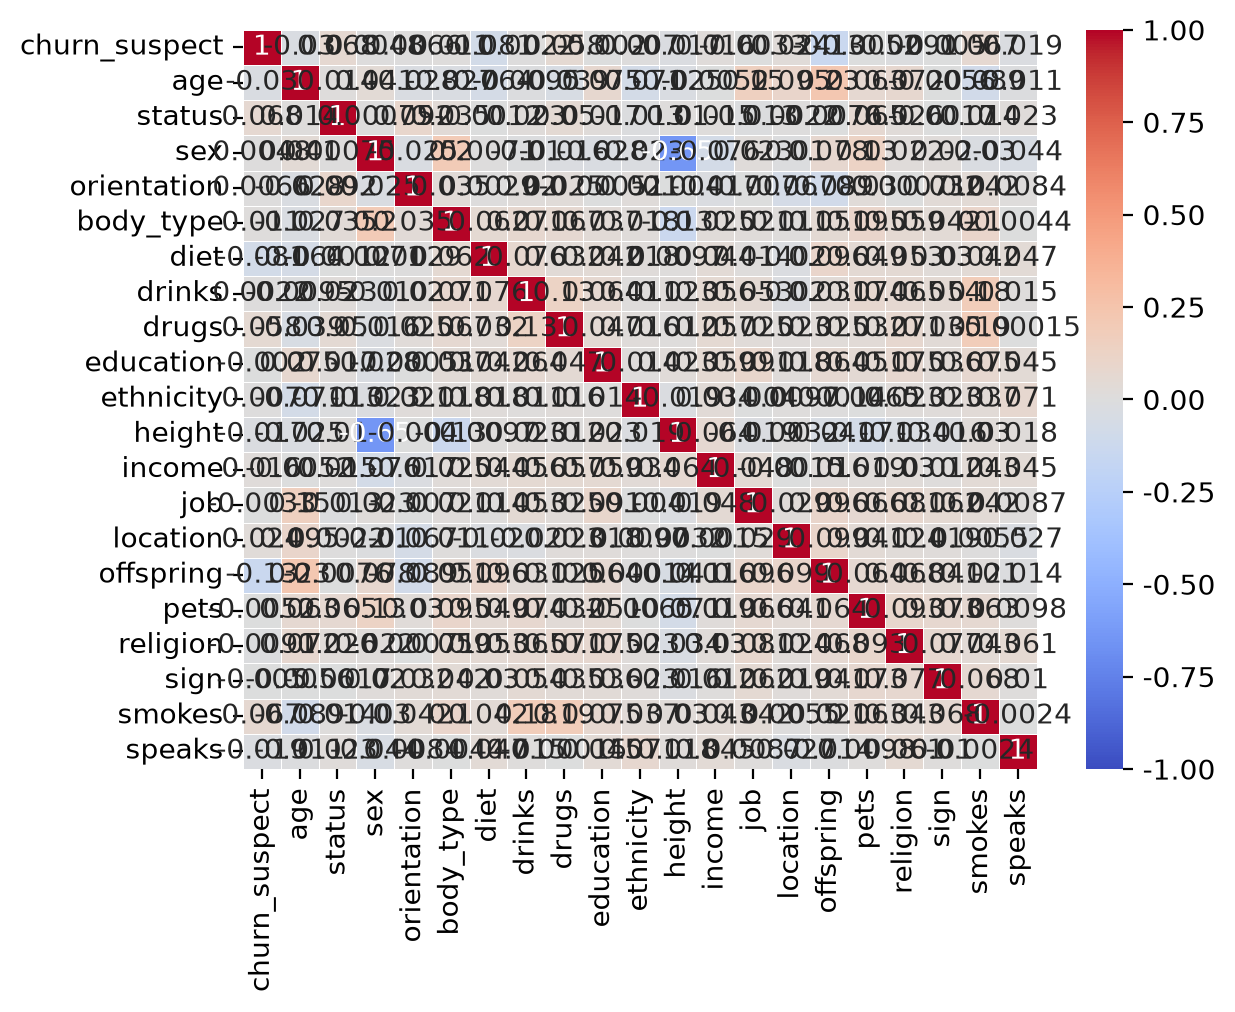

In [13]:
from common.show_graph import show_corr_map

essay_cols = [f"essay{i}" for i in range(10)]
show_corr_map(X_train, Y_train, essay_cols)

# EDA
- 성경님과 지수님이 짱 잘해주실거야 분명!!!

# Feature Extraction
- EDA만 잘하면 바로 만들 수 있지

In [14]:
import html

# 팀원이 선택한 최종 feature 14개
feature_list = [
    "actively_looking",
    "has_essay0",
    "essay_count",
    "profile_completeness",
    "religion_type",
    "edu_level",
    "wants_kids",
    "has_kids",
    "diet_type",
    "drugs_level",
    "job",
    "height",
    "status",
    "income",
    # 기존 EDA에서 확인한 핵심 후보 5개
    "essay_total_words", "smokes_level", "diet_strict", "edu_status", "age",
    # 팀원 제안 신규 feature 2개
    "has_kids_na", "profile_completeness_group",
    # essay 심화 후보 4개 (최종 채택 여부는 검증 후 결정)
    "essay_avg_len", "essay_almost_empty", "essay_len_std", "essay_has_link"
]

# profile_completeness 계산에 사용하는 프로필 항목 (팀원 노트북과 동일)
PROFILE = [
    "body_type", "diet_type", "diet_strict", "drinks_level", "drugs_level",
    "edu_level", "edu_status", "ethnicity_main", "job", "has_kids",
    "wants_kids", "pets_dog", "pets_cat", "religion_type",
    "religion_serious", "smokes_level", "zodiac"
]
ESSAY = [f"essay{i}" for i in range(10)]
MISSING_ESSAY = r"(?i)^\s*(?:[.\-?_/]+|na|n/a)\s*$"

DRINKS = {"not at all": 0, "rarely": 1, "socially": 2,
          "often": 3, "very often": 4, "desperately": 4}
DRUGS = {"never": 0, "sometimes": 1, "often": 2}
SMOKES = {"no": 0, "trying to quit": 1, "when drinking": 2,
          "sometimes": 3, "yes": 4}
EDU_LEVELS = ["high school", "two-year college", "college/university",
              "masters program", "law school", "med school",
              "ph.d program", "space camp"]
RELIGIONS = ["agnosticism", "atheism", "christianity", "judaism",
             "catholicism", "islam", "hinduism", "buddhism", "other"]


def diet_type(x):
    if pd.isna(x):
        return None
    return x.replace("mostly ", "").replace("strictly ", "")


def diet_strict(x):
    if pd.isna(x):
        return None
    if x.startswith("strictly"):
        return "strictly"
    if x.startswith("mostly"):
        return "mostly"
    return "plain"


def has_kids(x):
    if pd.isna(x):
        return None
    if x.startswith("has"):
        return 1
    if "doesn't have kids" in x:
        return 0
    return None


def wants_kids(x):
    if pd.isna(x):
        return None
    if "might want" in x:
        return "maybe"
    if "doesn't want" in x:
        return "no"
    if "wants" in x:
        return "yes"
    return None


def pet_attitude(text, animal):
    if pd.isna(text):
        return None
    for word in ["has", "dislikes", "likes"]:
        if f"{word} {animal}" in text:
            return word
    return None


def edu_level(x):
    if pd.isna(x):
        return None
    for level in EDU_LEVELS:
        if level in x:
            return level
    return None


def edu_status(x):
    if pd.isna(x):
        return None
    for status in ["graduated from", "working on", "dropped out of"]:
        if x.startswith(status):
            return status
    return None


def religion_type(x):
    if pd.isna(x):
        return None
    for religion in RELIGIONS:
        if x.startswith(religion):
            return religion
    return None


def religion_serious(x):
    if pd.isna(x):
        return None
    if "very serious" in x:
        return "very"
    if "somewhat serious" in x:
        return "somewhat"
    if "not too serious" in x:
        return "not much"
    if "laughing about" in x:
        return "joking"
    return "unsaid"


def main_ethnicity(x):
    if pd.isna(x):
        return None
    return x.split(",")[0].strip()


def zodiac(x):
    if pd.isna(x):
        return None
    return x.split()[0]


# ------------------ #
# feature_extraction #
# ------------------ #
def feature_extraction(df: pd.DataFrame) -> pd.DataFrame:
    # 원본을 유지하면서 feature 생성
    result = df.copy()

    # -------- #
    # cleaning #
    # -------- #
    text_cols = result.select_dtypes(include=["object", "string"]).columns
    for col in text_cols:
        result[col] = result[col].map(
            lambda x: html.unescape(x) if isinstance(x, str) else x
        )
    result[text_cols] = result[text_cols].replace(r"^\s*$", np.nan, regex=True)
    result[ESSAY] = result[ESSAY].replace(MISSING_ESSAY, np.nan, regex=True)

    # HTML의 &rsquo;가 변환된 곡선 따옴표도 자녀 응답에서 정상 인식
    offspring = result["offspring"].str.replace("’", "'", regex=False)

    # ------------------ #
    # 기본 응답에서 파생 #
    # ------------------ #
    result["actively_looking"] = result["status"].isin(["single", "available"]).astype(int)
    result["drinks_level"] = result["drinks"].map(DRINKS)
    result["drugs_level"] = result["drugs"].map(DRUGS)
    result["smokes_level"] = result["smokes"].map(SMOKES)
    result["diet_type"] = result["diet"].apply(diet_type)
    result["diet_strict"] = result["diet"].apply(diet_strict)
    result["has_kids"] = offspring.apply(has_kids)
    # 0: no, 1: yes뿐 아니라 응답 중 유무 불명확 / 미응답을 구별한 후
    # 미응답 플래그는 반드시 결측 대체 전에 생성한다.
    result["wants_kids"] = offspring.apply(wants_kids)
    result["pets_dog"] = result["pets"].apply(lambda x: pet_attitude(x, "dogs"))
    result["pets_cat"] = result["pets"].apply(lambda x: pet_attitude(x, "cats"))
    result["edu_level"] = result["education"].apply(edu_level)
    result["edu_status"] = result["education"].apply(edu_status)
    result["religion_type"] = result["religion"].apply(religion_type)
    result["religion_serious"] = result["religion"].apply(religion_serious)
    result["ethnicity_main"] = result["ethnicity"].apply(main_ethnicity)
    result["zodiac"] = result["sign"].apply(zodiac)

    # 결측치를 채우기 전에 응답한 프로필 항목 비율 / 에세이 수 계산
    result["profile_completeness"] = result[PROFILE].notna().mean(axis=1)
    result["essay_count"] = result[ESSAY].notna().sum(axis=1)
    result["has_essay0"] = result["essay0"].notna().astype(int)

    # 자녀 유무를 범주형으로 표현: 무응답과 자녀 유무를 명시하지 않은 응답을 구별
    # profile_completeness는 위에서 원래의 결측 상태로 계산을 마친 뒤 변경
    result["has_kids"] = result["has_kids"].map({0: "no", 1: "yes"})
    result.loc[result["has_kids"].isna() & offspring.notna(), "has_kids"] = "unspecified"
    result["has_kids_na"] = result["has_kids"].isna().astype("int8")

    # ----- Essay 심화 파생 변수: HTML 제거 후 사용자에게 보이는 텍스트 기준 -----
    clean = result[ESSAY].fillna("").apply(
        lambda col: col.str.replace(r"<[^>]+>", " ", regex=True)
                       .str.replace(r"\s+", " ", regex=True)
                       .str.strip()
    )
    lengths = clean.apply(lambda col: col.str.len())
    words = clean.apply(lambda col: col.str.count(r"\b\w+\b"))
    result["essay_total_len"] = lengths.sum(axis=1)
    result["essay_total_words"] = words.sum(axis=1)
    result["essay_avg_len"] = (
        result["essay_total_len"] / result["essay_count"].replace(0, np.nan)
    )
    result["essay_almost_empty"] = (result["essay_total_len"] <= 100).astype("int8")
    # 실제 작성한 essay의 길이만 이용; 0~1개 작성 시 NaN (CatBoost 처리)
    result["essay_len_std"] = lengths.where(result[ESSAY].notna()).std(axis=1)
    # '.'을 이스케이프해서 wwwx 같은 문자열이 URL로 오탐되지 않도록 함
    result["essay_has_link"] = clean.apply(
        lambda col: col.str.contains(r"https?://|www\.", case=False, regex=True)
    ).any(axis=1).astype("int8")
    # 추가 검토용. 총 단어 수/평균 길이/표준편차와 중복 가능성이 높아 기본 feature_list에서는 제외
    result["essay_max_len"] = lengths.max(axis=1)
    result["essay_longest_share"] = (
        result["essay_max_len"] / result["essay_total_len"].replace(0, np.nan)
    )
    result["essay_long_count"] = (lengths >= 500).sum(axis=1)

    # 이전 핵심 후보: 비현실적인 나이는 수치형 NaN으로 처리 (원본 age는 보존)
    result["age"] = pd.to_numeric(result["age"], errors="coerce").mask(
        lambda age: (age < 18) | (age > 90)
    )

    # income=-1은 공개하지 않은 소득이므로 실제 소득값으로 취급하지 않음
    result["income"] = result["income"].replace(-1, np.nan)

    return result


# Train/Test 독립적으로 생성한 후 profile_completeness의 구간 경계는 Train에서만 산출
train_all = feature_extraction(X_train)
test_all = feature_extraction(X_test)

# 원본 값이 17분의 정수여서 qcut 동점으로 경계가 중복될 수 있으므로 안전하게 처리
_, completeness_edges = pd.qcut(
    train_all["profile_completeness"], q=5, duplicates="drop", retbins=True
)
completeness_edges = np.unique(completeness_edges)
n_bins = len(completeness_edges) - 1
completeness_labels = {
    1: ["medium"],
    2: ["low", "high"],
    3: ["low", "medium", "high"],
    4: ["low", "medium_low", "medium_high", "high"],
    5: ["low", "medium_low", "medium", "medium_high", "high"],
}[n_bins]
completeness_edges[0] = -np.inf
completeness_edges[-1] = np.inf
for frame in (train_all, test_all):
    frame["profile_completeness_group"] = pd.cut(
        frame["profile_completeness"],
        bins=completeness_edges, labels=completeness_labels, include_lowest=True
    )

X_train = train_all[feature_list].copy()
X_test = test_all[feature_list].copy()

print("feature 개수 :", len(feature_list))
print(feature_list)

feature 개수 : 25
['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness', 'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type', 'drugs_level', 'job', 'height', 'status', 'income', 'essay_total_words', 'smokes_level', 'diet_strict', 'edu_status', 'age', 'has_kids_na', 'profile_completeness_group', 'essay_avg_len', 'essay_almost_empty', 'essay_len_std', 'essay_has_link']


## Essay 심화 EDA: 작성 개수와 작성 분량을 분리해서 보기

`has_kids_na`는 최종 `has_kids`의 무응답만 나타냅니다. `profile_completeness_group`은 **Train에서 산출한 구간 경계**를 Test에 그대로 적용합니다. `essay_len_std`는 0~1개 작성 시 NaN을 유지합니다. 링크 여부는 글에서 보이는 URL을 찾습니다(HTML `href` 속성은 제외).

아래 표는 **Train 데이터의 실제 30일 비활동 의심률**입니다. 타깃을 60일로 바꾸면 결과도 달라집니다. `last_online`은 입력 feature가 아닙니다.

In [15]:
# 14개 원래 feature + 5개 선행 핵심 후보 + 팀원 2개 + essay 4개
print("selected features:", feature_list)

eda_train = train_all.assign(churn_suspect=Y_train)
for col in ["has_kids_na", "profile_completeness_group", "essay_almost_empty", "essay_has_link"]:
    print(f"\n[{col}]")
    display(eda_train.groupby(col, observed=True)["churn_suspect"].agg(["size", "mean"]).round(4))

# 같은 수의 essay를 쓴 집단 안에서 평균 글 길이의 관계를 확인
essay_eda = eda_train[["essay_count", "essay_avg_len", "churn_suspect"]].copy()
essay_eda["count_group"] = pd.cut(
    essay_eda["essay_count"], [-1, 0, 3, 6, 9, 10], labels=["0", "1-3", "4-6", "7-9", "10"]
)
essay_eda["avg_group"] = pd.cut(
    essay_eda["essay_avg_len"], [-np.inf, 50, 150, 350, 700, np.inf],
    labels=["<=50", "51-150", "151-350", "351-700", ">700"]
)
display(essay_eda.groupby(["count_group", "avg_group"], observed=True)["churn_suspect"].agg(["size", "mean"]).round(4))

selected features: ['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness', 'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type', 'drugs_level', 'job', 'height', 'status', 'income', 'essay_total_words', 'smokes_level', 'diet_strict', 'edu_status', 'age', 'has_kids_na', 'profile_completeness_group', 'essay_avg_len', 'essay_almost_empty', 'essay_len_std', 'essay_has_link']

[has_kids_na]


,size,mean
has_kids_na,,
0,18368,0.1674
1,26591,0.3192



[profile_completeness_group]


,size,mean
profile_completeness_group,,
low,12304,0.3229
medium_low,10400,0.2788
medium,6540,0.2546
medium_high,10587,0.2219
high,5128,0.1320



[essay_almost_empty]


,size,mean
essay_almost_empty,,
0,42479,0.2401
1,2480,0.5504



[essay_has_link]


,size,mean
essay_has_link,,
0,42800,0.2619
1,2159,0.1635


size    mean
count_group avg_group               
1-3         <=50         668  0.4760
            51-150       811  0.4439
            151-350      709  0.3879
            351-700      395  0.3570
            >700         324  0.2994
4-6         <=50         448  0.4598
            51-150      1778  0.3408
            151-350     1807  0.2573
            351-700      671  0.1967
            >700         101  0.2475
7-9         <=50         495  0.4081
            51-150      4407  0.2843
            151-350     6567  0.1961
            351-700     1752  0.1787
            >700         145  0.1517
10          <=50         470  0.4532
            51-150      5243  0.2775
            151-350    11480  0.2055
            351-700     4508  0.1795
            >700         564  0.1507

In [16]:
# 전처리 전 결측 분포 확인: 실제 응답이 없는 비율을 보존하여 점검
missing_before = pd.DataFrame({
    "Train 결측(%)": X_train.isna().mean().mul(100).round(2),
    "Test 결측(%)": X_test.isna().mean().mul(100).round(2),
})
display(missing_before)

,Train 결측(%),Test 결측(%)
actively_looking,0.00,0.00
has_essay0,0.00,0.00
essay_count,0.00,0.00
profile_completeness,0.00,0.00
religion_type,33.82,33.49
edu_level,11.13,10.84
wants_kids,78.20,78.26
has_kids,59.14,59.85
diet_type,40.81,40.34
drugs_level,23.60,23.16


In [17]:
# CatBoost는 수치형 NaN을 직접 처리할 수 있음.
# 수치형을 무조건 중앙값으로 채우면 소득/약물 사용의 미응답을 실제 수치로 왜곡할 수 있으므로 유지.
# 범주형 결측은 별도 범주로 구분하고, has_kids의 no/yes/unspecified를 보존.
CAT_FEATURES = [
    "religion_type", "edu_level", "wants_kids", "has_kids",
    "diet_type", "job", "status",
    "diet_strict", "edu_status", "profile_completeness_group"
]
NUM_FEATURES = [col for col in feature_list if col not in CAT_FEATURES]


def catboost_cleansing(train: pd.DataFrame, test: pd.DataFrame):
    cleansed_train = train.copy()
    cleansed_test = test.copy()

    for features in [cleansed_train, cleansed_test]:
        for col in CAT_FEATURES:
            features[col] = (
                features[col].astype("string")
                .fillna("not_disclosed")
                .astype("category")
            )
        for col in NUM_FEATURES:
            features[col] = pd.to_numeric(features[col], errors="raise")

    return cleansed_train, cleansed_test


X_train, X_test = catboost_cleansing(X_train, X_test)

In [18]:
X_train.shape, X_test.shape

((44959, 25), (14987, 25))

In [19]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("feature list\n", X_train.columns)

X_train: (44959, 25)
X_test : (14987, 25)
feature list
 Index(['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness',
       'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type',
       'drugs_level', 'job', 'height', 'status', 'income', 'essay_total_words',
       'smokes_level', 'diet_strict', 'edu_status', 'age', 'has_kids_na',
       'profile_completeness_group', 'essay_avg_len', 'essay_almost_empty',
       'essay_len_std', 'essay_has_link'],
      dtype='str')


## Cleansing Check

CatBoost는 **수치형 NaN을 직접 처리**하므로 `income`, `drugs_level`, `height` 결측을 임의의 중앙값으로 채우지 않는다. 범주형에서 응답하지 않은 경우는 `not_disclosed` 범주로 남긴다. `has_kids`의 `unspecified`는 자녀 유무 대신 희망만 응답한 사람으로, 완전 무응답과 다르게 처리한다.

In [20]:
# 범주형 결측은 없어야 함. 수치형 결측은 의도적으로 남겨 둠.
for name, features in [("X_train", X_train), ("X_test", X_test)]:
    cat_null = features[CAT_FEATURES].isna().sum().sum()
    num_null = features[NUM_FEATURES].isna().sum().sum()
    print(f"{name} 범주형 결측: {cat_null}개")
    print(f"{name} 수치형 결측: {num_null}개 (CatBoost가 직접 처리)")
    assert cat_null == 0, f"{name}에 범주형 결측이 남았습니다."

print("\nhas_kids (Train):")
print(X_train["has_kids"].value_counts(dropna=False))

X_train 범주형 결측: 0개
X_train 수치형 결측: 55594개 (CatBoost가 직접 처리)
X_test 범주형 결측: 0개
X_test 수치형 결측: 18353개 (CatBoost가 직접 처리)

has_kids (Train):
has_kids
not_disclosed    26591
no               12159
yes               3720
unspecified       2489
Name: count, dtype: int64


# Data Preprocessing

In [21]:
from common.preprocessing import smotenc_sampling

# SMOTE를 쓰려면 essay는 물론 다른 컬럼들도 손봐야 함.

# Modeling

## Dimension Check

In [22]:
# 모델에게 학습시키기 전 차원 검증
assert X_train.shape[0] == Y_train.shape[0], "학습 데이터 수 != 타겟 데이터 수"
assert X_test.shape[0] == Y_test.shape[0], "테스트 데이터 수 != 타켓 데이터 수"
assert X_train.shape[1] == X_test.shape[1], "학습 컬럼 수 != 테스트 컬럼 수"

## Model 정의

In [23]:
X_train.dtypes.value_counts()

float64     8
int64       4
int8        3
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

In [ ]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight

# sklearn에서 계산한 class weights 사용 (hypo)
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=Y_train
).tolist()
print("class_weights:", class_weights)

hp = {
    "class_weights":class_weights   # SMOTE 쓰기 전 가벼운 코딩
}

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# 모델 정의 (Random Search + Bayesian Search 탐색값)
def make_catboost(cat_features, class_weights=class_weights):
    return CatBoostClassifier(
        random_seed=42,             # 시드 고정
        verbose=0,                  # 부스팅 단계 출력 안보이게 하기
        cat_features=cat_features,  # 범주형 데이터 알려주기
        allow_writing_files=False,  # 학습 내용 파일로 저장 금지
        class_weights=class_weights # SMOTE 쓰기 전 가벼운 코딩
    )

class_weights: [0.6731396915705944, 1.9439207886544447]


### Train 내부 Validation으로 분류 임계값 비교

ROC-AUC/AP는 확률값의 순위 평가이고, Accuracy/Precision/Recall/F1은 임계값에 영향을 받습니다. **Test 성능으로 임계값을 고르면 안 됩니다.** 아래는 Train 안에서 80:20으로 따로 나눠 운영 목적에 맞는 임계값 후보를 확인합니다. 전체 0.7 달성을 보장하지 않습니다.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=2026, stratify=Y_train
)
inner_class_weights = compute_class_weight(
    "balanced", classes=np.array([0, 1]), y=y_fit
).tolist()

# 최종 Test는 사용하지 않은 별도의 탐색용 모델
inner_model = make_catboost(cat_cols, class_weights=inner_class_weights)
inner_model.fit(X_fit, y_fit)
valid_proba = inner_model.predict_proba(X_valid)[:, 1]
metric_rows = []
for th in np.arange(0.20, 0.801, 0.02):
    valid_pred = (valid_proba >= th).astype(int)
    metric_rows.append({
        "threshold": round(float(th), 2),
        "accuracy": accuracy_score(y_valid, valid_pred),
        "precision": precision_score(y_valid, valid_pred, zero_division=0),
        "recall": recall_score(y_valid, valid_pred, zero_division=0),
        "f1": f1_score(y_valid, valid_pred, zero_division=0),
    })
threshold_results = pd.DataFrame(metric_rows)
print("Train 내부 ROC-AUC:", roc_auc_score(y_valid, valid_proba))
print("Train 내부 AP:", average_precision_score(y_valid, valid_proba))
print("F1 최고 임계값 후보 (이 Validation 분할에서만 평가):")
display(threshold_results.sort_values("f1", ascending=False).head(10))


NameError: name 'cat_cols' is not defined

## Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

# 교차 검증 (타겟 클래스 비율을 맞춰 KFold하는 CV)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
def run_strat_kfold(skf:StratifiedKFold, X_train:pd.DataFrame, Y_train:pd.DataFrame, cat_cols:list) -> list:
    AUC_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, Y_train), 1):
        # skf가 분리해준대로 train과 val 생성
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        Y_tr, Y_va = Y_train.iloc[tr_idx], Y_train.iloc[va_idx]

        model = make_catboost(cat_cols) # fold마다 새 모델 생성
        model.fit(X_tr, Y_tr)       # 학습

        pred = model.predict_proba(X_va)[:, 1]  # 예측
        auc_score = roc_auc_score(Y_va, pred)   # ROC-AUC 로 평가
        AUC_scores.append(auc_score)            # AUC_scores에 추가
        print(f"{fold}번째 Stratified K-Fold의 AUC 점수: {auc_score}")  # 점수 반환

    return AUC_scores


# # Stratified K-Fold 진행
# cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
# cv_scores = run_strat_kfold(skf, X_train, Y_train, cat_cols)
# print('-'*50)
# print(f"Stratified 5-Fold 평균 ROC-AUC: {np.mean(cv_scores):.5f}")
# print(f"Stratified 5-Fold ROC-AUC 표준편차: {np.std(cv_scores):.5f}")

# Evaluation

## 평가 지표

In [ ]:
# train 데이터 학습 및 평가
cat_model = make_catboost(cat_cols)
cat_model.fit(X_train, Y_train)

train_pred = cat_model.predict(X_train).astype(int).ravel()
print(f"Train Accuracy : {accuracy_score(Y_train, train_pred):.5f}")


# test 데이터 학습 및 평가
test_pred = cat_model.predict(X_test).astype(int).ravel()
test_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(Y_test, test_pred)
precision = precision_score(Y_test, test_pred)
recall = recall_score(Y_test, test_pred)
f1 = f1_score(Y_test, test_pred)
roc_auc = roc_auc_score(Y_test, test_proba)
pr_auc = average_precision_score(Y_test, test_proba)

overall_score = np.mean([precision, recall, f1, roc_auc, pr_auc])


print(f"Valid Accuracy : {accuracy:.5f}")
print(f"Precision      : {precision:.5f}")
print(f"Recall         : {recall:.5f}")
print(f"F1-score       : {f1:.5f}")
print(f"ROC-AUC        : {roc_auc:.5f}")
print(f"PR-AUC         : {pr_auc:.5f}")
print(f"Overall Score  : {overall_score:.5f}")

## Confusion matrix

In [ ]:
from common.evaluation_plots import show_norm_conf_mx

show_norm_conf_mx(y=Y_test, pred=test_pred)

## ROC Curve

In [ ]:
from sklearn.dummy import DummyClassifier

# Dummy 모델
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)

pred_dummy = dummy.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(Y_test, test_proba, name='CatBoost',ax=ax)
RocCurveDisplay.from_predictions(Y_test, pred_dummy, name='dummy', ax=ax)
plt.title("Validation ROC Curve")
plt.show()

## XAI (SHAP)

In [ ]:
import shap

# 학습된 모델을 넣는다.
explainer = shap.TreeExplainer(cat_model)
# 학습된 모델을 갖고 X_val를 분석
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[-1]

shap_values = np.asarray(shap_values)

In [ ]:
shap_values[1].shape , X_test.shape

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
explainer=shap.TreeExplainer(cat_model)
sv=explainer.shap_values(X_test)
if isinstance(sv,list): sv=sv[-1]
sv=np.asarray(sv)
shap_rank=pd.DataFrame({'feature':X_test.columns,'mean_abs_shap':np.abs(sv).mean(axis=0)}).sort_values('mean_abs_shap',ascending=False)
shap_rank.head(30)


In [ ]:
# 수치형 feature만 보기
selected_features = X_test.select_dtypes(include=np.number).columns.tolist()
# X_val에서 해당 feature의 위치
selected_idx = [X_test.columns.get_loc(col) for col in selected_features]

# 원하는 feature만 SHAP plot
shap.summary_plot(
    shap_values[:, selected_idx],
    X_test[selected_features]
)

In [ ]:
# 범주형 feature만 보기
selected_features = X_test.select_dtypes(exclude=np.number).columns.tolist()
selected_idx = [X_test.columns.get_loc(col) for col in selected_features]

shap.summary_plot(
    shap_values[:, selected_idx],
    X_test[selected_features]
)

# 모델 저장

In [ ]:
from datetime import datetime
from pathlib import Path

# 진짜 저장할거야? 진짜?
# 진짜루??????
answer = input("모델을 저장하려면 'Y'를 눌러주세요: ")

if answer.upper() == "Y":
    # 저장 폴더 생성
    Path("models").mkdir(parents=True, exist_ok=True)

    # 현재 시각으로 파일명 생성
    timestamp = datetime.now().strftime("%m_%d_%H_%M")
    model_path = f"models/okcupid_model_{timestamp}.cbm"

    # 모델 저장
    cat_model.save_model(model_path)
    print(f"저장 완료: {model_path}")


# # 로드는 아래와 같이 해주세요.
# model = CatBoostClassifier()
# model.load_model("models/okcupid_model.cbm")